# Ejercicio 4

1. Proponga una combinación de técnicas para realzar los detalles de la imagen `esqueleto.tif`. Recuerde que esta tarea es subjetiva y depende de qué pretende realzar. Justifique cada una de las elecciones en la elaboración de su propuesta.

Primer se analiza la imagen observandola

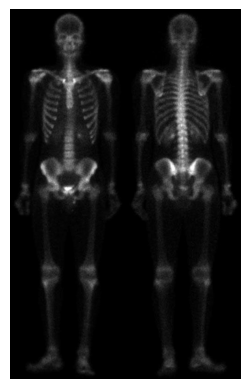

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
import helpers

esqueleto = cv2.imread("esqueleto.tif", cv2.IMREAD_GRAYSCALE)
fig, ax = plt.subplots(1, 1)
ax.imshow(esqueleto, cmap="gray")
ax.axis("off")
plt.show()

Se prueban transformaciones para realzar la imagen, logaritmicas y exponenciales.

> Se prueba con sliders interactivos pero luego se muestra el resultado mas prometedor. La exponencial con 0.5 es la que parece realzar mejor los detalles sin introducir demasiado ruido

In [13]:
lut_log = helpers.LUTLog()
# funcion de actualizacion
def actualizar(tipo, gamma):
    if tipo == "log":
        img_t = lut_log[esqueleto[:]]
    else:
        lut_exp = helpers.LUTPotencia(gamma)
        img_t = lut_exp[esqueleto[:]]

    fig, ax = plt.subplots(1, 2, figsize=(10, 15))

    # img original
    ax[0].imshow(esqueleto, cmap="gray")
    ax[0].set_title("Original")
    ax[0].axis("off")

    # img filtrada
    ax[1].imshow(img_t, cmap="gray")
    ax[1].set_title(f"Filtrada")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

interact(
    actualizar,
    tipo=Dropdown(
        options=["log", "exp"],
        value="log",
        description="tipo de T"
    ),
    gamma=FloatSlider(
        value=1,
        min=0.1,
        max=5,
        step=0.1,
        description="gamma"
    )
);

interactive(children=(Dropdown(description='tipo de T', options=('log', 'exp'), value='log'), FloatSlider(valu…

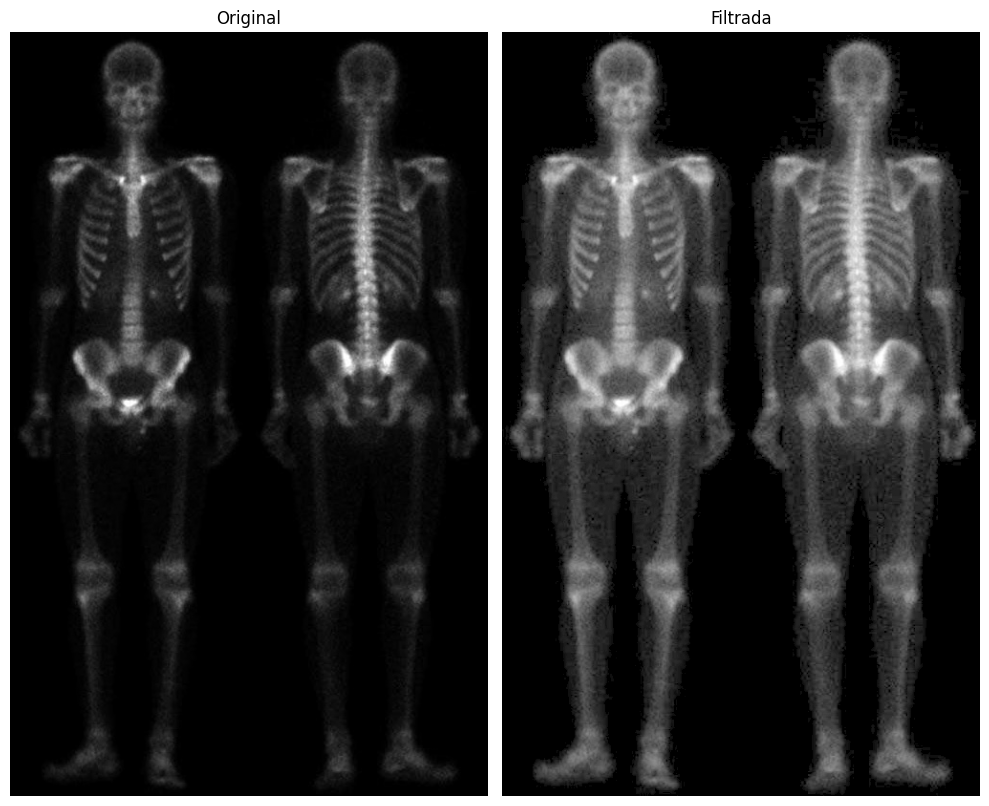

In [14]:
lut_exp = helpers.LUTPotencia(gamma=0.5)
esqueleto_t = lut_exp[esqueleto[:]]

fig, ax = plt.subplots(1, 2, figsize=(10, 15))

# img original
ax[0].imshow(esqueleto, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

# img filtrada
ax[1].imshow(esqueleto_t, cmap="gray")
ax[1].set_title(f"Filtrada")
ax[1].axis("off")

plt.tight_layout()
plt.show()

Luego vamos a querer filtrar la silueta (umbralización) y realzar aun mas las altas frecuencias (detalles), por lo que probamos un highboost con distintos valores de A.

> Otra vez, probaremos los valores de umbralizacion y A con sliders interactivos, luego se muestran los resultados mas prometedores.

In [15]:
# funcion de actualizacion
def actualizar(umbral, A):
    A = 1 if A==1.0 else A
    # umbralizar
    _, mask = cv2.threshold(src=esqueleto_t, thresh=umbral, maxval=255, type=cv2.THRESH_BINARY)
    esqueleto_umbral = helpers.multiplicacion(esqueleto_t, mask)

    # highboost
    esqueleto_f = helpers.altaPotencia(img=esqueleto_umbral, A=A)

    fig, ax = plt.subplots(1, 3, figsize=(10, 15))

    # transformada
    ax[0].imshow(esqueleto_t, cmap="gray")
    ax[0].set_title("transformada")
    ax[0].axis("off")

    # umbralizada
    ax[1].imshow(esqueleto_umbral, cmap="gray")
    ax[1].set_title(f"umbralizada")
    ax[1].axis("off")

    # filtro high boost
    ax[2].imshow(esqueleto_f, cmap="gray")
    ax[2].set_title(f"high boost")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

interact(
    actualizar,
    umbral=FloatSlider(
        value=5,
        min=5,
        max=100,
        step=1,
        description="umbral"
    ),
    A=FloatSlider(
        value=1,
        min=1,
        max=10,
        step=0.1,
        description="A"
    )
);

interactive(children=(FloatSlider(value=5.0, description='umbral', min=5.0, step=1.0), FloatSlider(value=1.0, …

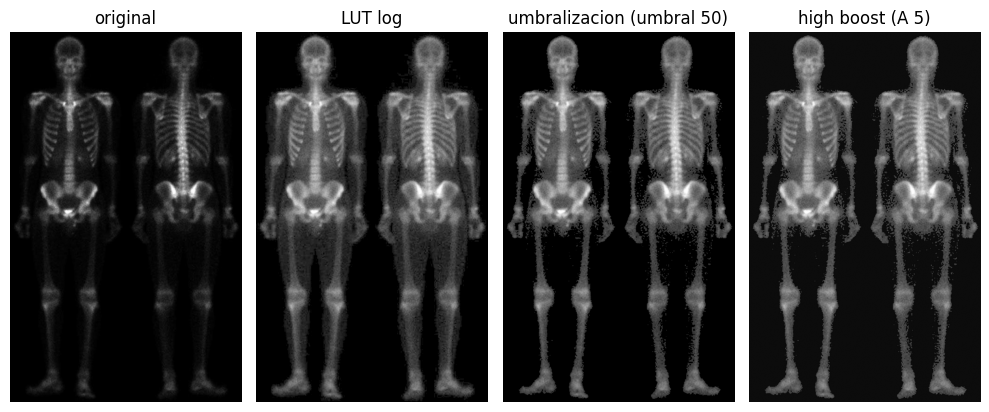

In [16]:
# umbralizar
umbral = 50
_, mask = cv2.threshold(src=esqueleto_t, thresh=umbral, maxval=255, type=cv2.THRESH_BINARY)
esqueleto_umbral = helpers.multiplicacion(esqueleto_t, mask)

# highboost
A = 5
esqueleto_f = helpers.altaPotencia(img=esqueleto_umbral, A=A)

fig, ax = plt.subplots(1, 4, figsize=(10, 15))

# original
ax[0].imshow(esqueleto, cmap="gray")
ax[0].set_title("original")
ax[0].axis("off")

# transformada
ax[1].imshow(esqueleto_t, cmap="gray")
ax[1].set_title("LUT log")
ax[1].axis("off")

# umbralizada
ax[2].imshow(esqueleto_umbral, cmap="gray")
ax[2].set_title(f"umbralizacion (umbral {umbral})")
ax[2].axis("off")

# filtro high boost
ax[3].imshow(esqueleto_f, cmap="gray")
ax[3].set_title(f"high boost (A {A})")
ax[3].axis("off")

plt.tight_layout()
plt.show()

2. Aplique un filtro pasa-bajos de su elección y el filtro bilateral a las siguientes imágenes: `mariposa02.png`, `flores02.jpg` y `lapices02.jpg` (en escala de grises).
Compare los resultados y explique sus apreciaciones.

- Utilice la función implementada en la guía anterior para visualizar perfiles de grises, eligiendo la misma fila o columna para la imagen original y las que han sido filtradas. Compare los resultados visualizándolos simultáneamente.
- [Opcional] Implemente una función que le permita extraer perfiles de grises de las 3 imágenes, de cualquier longitud y en cualquier dirección (a partir de clicks del mouse o mediante el ingreso de coordenadas) y que realice el ploteo de los perfiles superpuestos en difernetes colores.

> Los parametros para los filtros se encontraron probando distintos y quedandonos con los que parecian mejores.
> 
> La parte interactiva se hace desde jupyter notebooks con ipywidgets

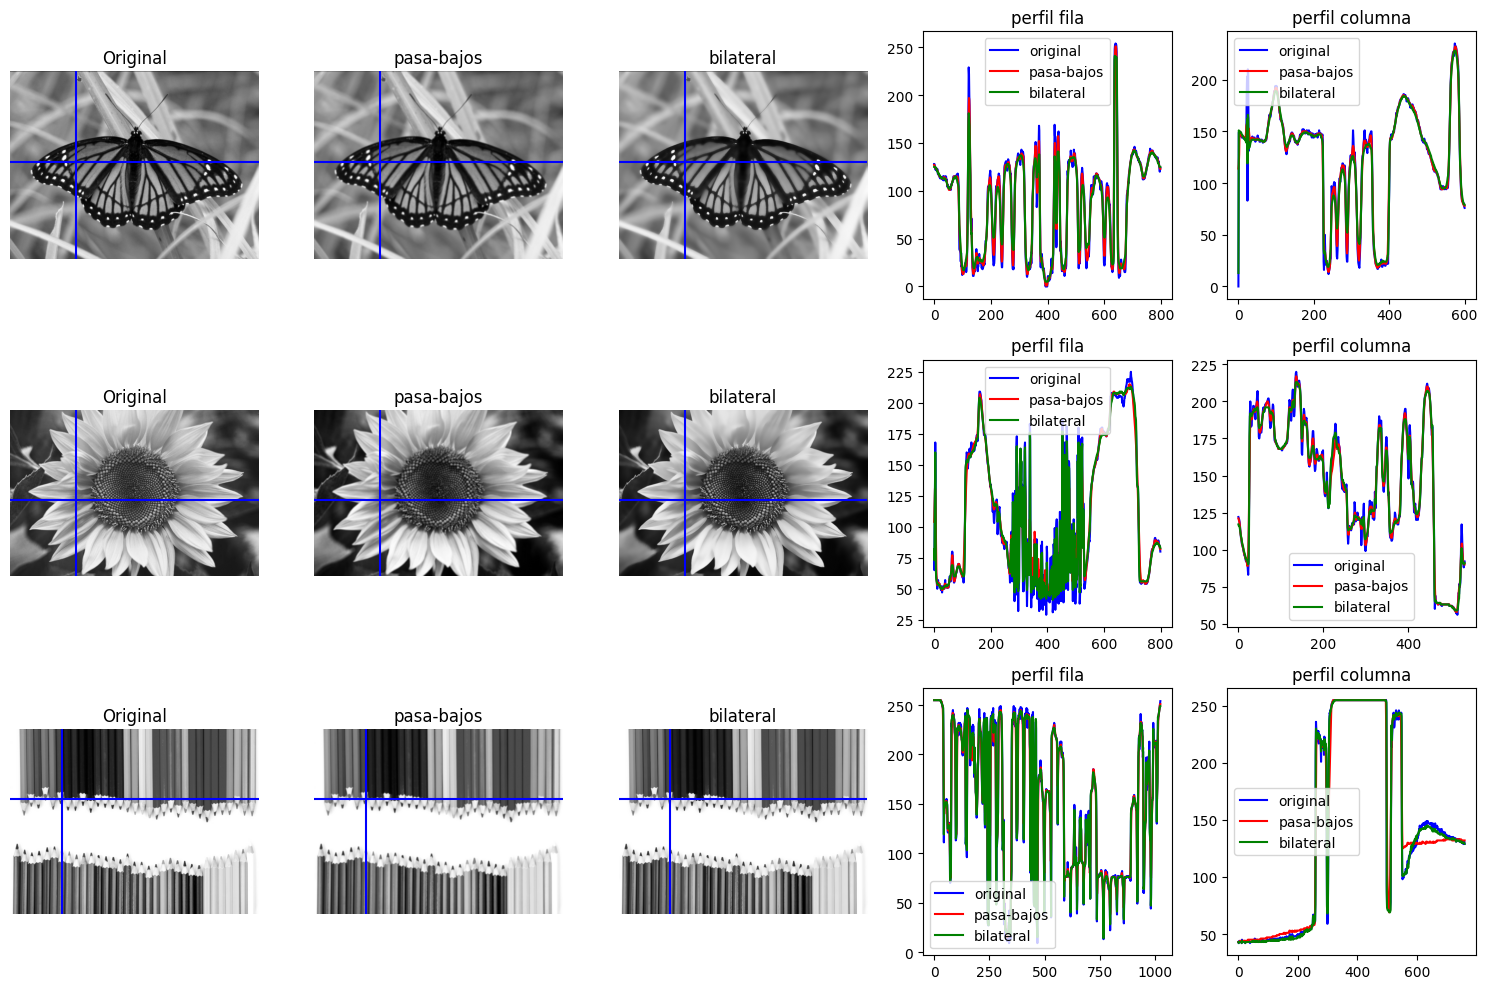

In [17]:
mariposa = cv2.imread("mariposa02.png", cv2.IMREAD_GRAYSCALE)
mariposa_pb = cv2.GaussianBlur(mariposa, (5, 5), 2)
mariposa_bi = cv2.bilateralFilter(mariposa, 15, 50, 50)
flores = cv2.imread("flores02.jpg", cv2.IMREAD_GRAYSCALE)
flores_pb = cv2.GaussianBlur(flores, (5, 5), 2)
flores_bi = cv2.bilateralFilter(flores, 15, 15, 15)
lapices = cv2.imread("lapices02.jpg", cv2.IMREAD_GRAYSCALE)
lapices_pb = cv2.GaussianBlur(lapices, (5, 5), 2)
lapices_bi = cv2.bilateralFilter(lapices, 15, 10, 10)

row = 289
col = 212

fig, ax = plt.subplots(3, 5, figsize=(15, 10))

# original
ax[0][0].imshow(mariposa, cmap="gray")
ax[0][0].plot([0, mariposa.shape[1]-1], [row, row], c="blue")
ax[0][0].plot([col, col], [0, mariposa.shape[0]-1], c="blue")
ax[0][0].set_title("Original")
ax[0][0].axis("off")
ax[1][0].imshow(flores, cmap="gray")
ax[1][0].plot([0, flores.shape[1]-1], [row, row], c="blue")
ax[1][0].plot([col, col], [0, flores.shape[0]-1], c="blue")
ax[1][0].set_title("Original")
ax[1][0].axis("off")
ax[2][0].imshow(lapices, cmap="gray")
ax[2][0].plot([0, lapices.shape[1]-1], [row, row], c="blue")
ax[2][0].plot([col, col], [0, lapices.shape[0]-1], c="blue")
ax[2][0].set_title("Original")
ax[2][0].axis("off")

# pasa-bajos
ax[0][1].imshow(mariposa_pb, cmap="gray")
ax[0][1].plot([0, mariposa_pb.shape[1]-1], [row, row], c="blue")
ax[0][1].plot([col, col], [0, mariposa_pb.shape[0]-1], c="blue")
ax[0][1].set_title("pasa-bajos")
ax[0][1].axis("off")
ax[1][1].imshow(flores_pb, cmap="gray")
ax[1][1].plot([0, flores_pb.shape[1]-1], [row, row], c="blue")
ax[1][1].plot([col, col], [0, flores_pb.shape[0]-1], c="blue")
ax[1][1].set_title("pasa-bajos")
ax[1][1].axis("off")
ax[2][1].imshow(lapices_pb, cmap="gray")
ax[2][1].plot([0, lapices_pb.shape[1]-1], [row, row], c="blue")
ax[2][1].plot([col, col], [0, lapices_pb.shape[0]-1], c="blue")
ax[2][1].set_title("pasa-bajos")
ax[2][1].axis("off")

# bilateral
ax[0][2].imshow(mariposa_bi, cmap="gray")
ax[0][2].plot([0, mariposa_bi.shape[1]-1], [row, row], c="blue")
ax[0][2].plot([col, col], [0, mariposa_bi.shape[0]-1], c="blue")
ax[0][2].set_title("bilateral")
ax[0][2].axis("off")
ax[1][2].imshow(flores_bi, cmap="gray")
ax[1][2].plot([0, flores_bi.shape[1]-1], [row, row], c="blue")
ax[1][2].plot([col, col], [0, flores_bi.shape[0]-1], c="blue")
ax[1][2].set_title("bilateral")
ax[1][2].axis("off")
ax[2][2].imshow(lapices_bi, cmap="gray")
ax[2][2].plot([0, lapices_bi.shape[1]-1], [row, row], c="blue")
ax[2][2].plot([col, col], [0, lapices_bi.shape[0]-1], c="blue")
ax[2][2].set_title("bilateral")
ax[2][2].axis("off")

# perfil fila
ax[0][3].plot(mariposa[row,:], c="blue", label="original")
ax[0][3].plot(mariposa_pb[row,:], c="red", label="pasa-bajos")
ax[0][3].plot(mariposa_bi[row,:], c="green", label="bilateral")
ax[0][3].legend()
ax[0][3].set_title(f"perfil fila")
ax[1][3].plot(flores[row,:], c="blue", label="original")
ax[1][3].plot(flores_pb[row,:], c="red", label="pasa-bajos")
ax[1][3].plot(flores_bi[row,:], c="green", label="bilateral")
ax[1][3].legend()
ax[1][3].set_title(f"perfil fila")
ax[2][3].plot(lapices[row,:], c="blue", label="original")
ax[2][3].plot(lapices_pb[row,:], c="red", label="pasa-bajos")
ax[2][3].plot(lapices_bi[row,:], c="green", label="bilateral")
ax[2][3].legend()
ax[2][3].set_title(f"perfil fila")

# perfil columna
ax[0][4].plot(mariposa[:,col], c="blue", label="original")
ax[0][4].plot(mariposa_pb[:,col], c="red", label="pasa-bajos")
ax[0][4].plot(mariposa_bi[:,col], c="green", label="bilateral")
ax[0][4].legend()
ax[0][4].set_title(f"perfil columna")
ax[1][4].plot(flores[:,col], c="blue", label="original")
ax[1][4].plot(flores_pb[:,col], c="red", label="pasa-bajos")
ax[1][4].plot(flores_bi[:,col], c="green", label="bilateral")
ax[1][4].legend()
ax[1][4].set_title(f"perfil columna")
ax[2][4].plot(lapices[:,col], c="blue", label="original")
ax[2][4].plot(lapices_pb[:,col], c="red", label="pasa-bajos")
ax[2][4].plot(lapices_bi[:,col], c="green", label="bilateral")
ax[2][4].legend()
ax[2][4].set_title(f"perfil columna")

plt.tight_layout()
plt.show()

In [18]:
# funcion de actualizacion
def actualizar(row, col):
    fig, ax = plt.subplots(3, 5, figsize=(15, 10))

    # original
    ax[0][0].imshow(mariposa, cmap="gray")
    ax[0][0].plot([0, mariposa.shape[1]-1], [row, row], c="blue")
    ax[0][0].plot([col, col], [0, mariposa.shape[0]-1], c="blue")
    ax[0][0].set_title("Original")
    ax[0][0].axis("off")
    ax[1][0].imshow(flores, cmap="gray")
    ax[1][0].plot([0, flores.shape[1]-1], [row, row], c="blue")
    ax[1][0].plot([col, col], [0, flores.shape[0]-1], c="blue")
    ax[1][0].set_title("Original")
    ax[1][0].axis("off")
    ax[2][0].imshow(lapices, cmap="gray")
    ax[2][0].plot([0, lapices.shape[1]-1], [row, row], c="blue")
    ax[2][0].plot([col, col], [0, lapices.shape[0]-1], c="blue")
    ax[2][0].set_title("Original")
    ax[2][0].axis("off")

    # pasa-bajos
    ax[0][1].imshow(mariposa_pb, cmap="gray")
    ax[0][1].plot([0, mariposa_pb.shape[1]-1], [row, row], c="blue")
    ax[0][1].plot([col, col], [0, mariposa_pb.shape[0]-1], c="blue")
    ax[0][1].set_title("pasa-bajos")
    ax[0][1].axis("off")
    ax[1][1].imshow(flores_pb, cmap="gray")
    ax[1][1].plot([0, flores_pb.shape[1]-1], [row, row], c="blue")
    ax[1][1].plot([col, col], [0, flores_pb.shape[0]-1], c="blue")
    ax[1][1].set_title("pasa-bajos")
    ax[1][1].axis("off")
    ax[2][1].imshow(lapices_pb, cmap="gray")
    ax[2][1].plot([0, lapices_pb.shape[1]-1], [row, row], c="blue")
    ax[2][1].plot([col, col], [0, lapices_pb.shape[0]-1], c="blue")
    ax[2][1].set_title("pasa-bajos")
    ax[2][1].axis("off")

    # bilateral
    ax[0][2].imshow(mariposa_bi, cmap="gray")
    ax[0][2].plot([0, mariposa_bi.shape[1]-1], [row, row], c="blue")
    ax[0][2].plot([col, col], [0, mariposa_bi.shape[0]-1], c="blue")
    ax[0][2].set_title("bilateral")
    ax[0][2].axis("off")
    ax[1][2].imshow(flores_bi, cmap="gray")
    ax[1][2].plot([0, flores_bi.shape[1]-1], [row, row], c="blue")
    ax[1][2].plot([col, col], [0, flores_bi.shape[0]-1], c="blue")
    ax[1][2].set_title("bilateral")
    ax[1][2].axis("off")
    ax[2][2].imshow(lapices_bi, cmap="gray")
    ax[2][2].plot([0, lapices_bi.shape[1]-1], [row, row], c="blue")
    ax[2][2].plot([col, col], [0, lapices_bi.shape[0]-1], c="blue")
    ax[2][2].set_title("bilateral")
    ax[2][2].axis("off")

    # perfil fila
    ax[0][3].plot(mariposa[row,:], c="blue", label="original")
    ax[0][3].plot(mariposa_pb[row,:], c="red", label="pasa-bajos")
    ax[0][3].plot(mariposa_bi[row,:], c="green", label="bilateral")
    ax[0][3].legend()
    ax[0][3].set_title(f"perfil fila")
    ax[1][3].plot(flores[row,:], c="blue", label="original")
    ax[1][3].plot(flores_pb[row,:], c="red", label="pasa-bajos")
    ax[1][3].plot(flores_bi[row,:], c="green", label="bilateral")
    ax[1][3].legend()
    ax[1][3].set_title(f"perfil fila")
    ax[2][3].plot(lapices[row,:], c="blue", label="original")
    ax[2][3].plot(lapices_pb[row,:], c="red", label="pasa-bajos")
    ax[2][3].plot(lapices_bi[row,:], c="green", label="bilateral")
    ax[2][3].legend()
    ax[2][3].set_title(f"perfil fila")

    # perfil columna
    ax[0][4].plot(mariposa[:,col], c="blue", label="original")
    ax[0][4].plot(mariposa_pb[:,col], c="red", label="pasa-bajos")
    ax[0][4].plot(mariposa_bi[:,col], c="green", label="bilateral")
    ax[0][4].legend()
    ax[0][4].set_title(f"perfil columna")
    ax[1][4].plot(flores[:,col], c="blue", label="original")
    ax[1][4].plot(flores_pb[:,col], c="red", label="pasa-bajos")
    ax[1][4].plot(flores_bi[:,col], c="green", label="bilateral")
    ax[1][4].legend()
    ax[1][4].set_title(f"perfil columna")
    ax[2][4].plot(lapices[:,col], c="blue", label="original")
    ax[2][4].plot(lapices_pb[:,col], c="red", label="pasa-bajos")
    ax[2][4].plot(lapices_bi[:,col], c="green", label="bilateral")
    ax[2][4].legend()
    ax[2][4].set_title(f"perfil columna")

    plt.tight_layout()
    plt.show()

interact(
    actualizar,
    row=IntSlider(
        value=100,
        min=2,
        max=500,
        step=1,
        description="fila"
    ),
    col=IntSlider(
        value=100,
        min=2,
        max=500,
        step=1,
        description="columna"
    )
);

interactive(children=(IntSlider(value=100, description='fila', max=500, min=2), IntSlider(value=100, descripti…

Ambos filtros suavizan la imagen y reducen en distintos niveles el ruido, pero el bilateral logra mantener mejor los detalles (bordes).

En el pasa-bajos el kernel es el parámetros que hay que manejar con más cuidado, ya que es muy facil perder bordes, pero con uno muy chico (3,3) no se alcanzaría a sacar el ruido, como puede ser el caso de la mariposa.

En el bilateral tenemos más parametros para "jugar" por lo que lleva más tiempo encontrar los que más nos sirven, pero logramos mejores resultados que con el pasa-bajos, reduciendo el ruido sin perder tantos detalles (bordes).

En ambos casos pueden apreciarse en los perfiles una reducción en los cambios abrúptos. El perfil de la imagen original (azul) siempre tiene picos más acentuados que el de cualquiera de las versiones filtradas. Esto concuerda con el proceso que estamos realizando, donde tratamos de reducir frecuencias altas y en ciertos lugares el filtro bilateral presenta menos picos que el pasa-bajos gaussiano 